# Фінальна робота: оптимізація параметрів класифікатора
## Breast Cancer Wisconsin (Diagnostic)

Підсумкова робота курсу *Numerical Programming in Python*. На наборі **Breast Cancer Wisconsin** послідовно застосуємо всі ключові методи курсу:

1. Розвідувальний аналіз та попарні діаграми;
2. **Кластеризацію** (Spectral, K-Means, GMM) і порівняння з класами;
3. **Зменшення розмірності** (PCA) та візуалізацію;
4. **Класифікацію** логістичною регресією трьома способами оптимізації параметрів:
   - бібліотечний `LogisticRegression`;
   - власна реалізація з **градієнтним спуском** (Batch, SGD, RMSProp, Adam, Nadam);
   - оптимізація ваг **генетичним алгоритмом** (`PyGad`);
5. Оцінку якості кожної моделі (`confusion_matrix`, `f1_score`) та висновки.

## Імпорти

In [1]:
!pip install pygad

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pygad

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, f1_score, accuracy_score,
                             adjusted_rand_score, ConfusionMatrixDisplay)

np.random.seed(42)
%matplotlib inline

## 1. Завантаження даних

In [2]:
data = load_breast_cancer()
X = data.data          # ознаки
y = data.target        # 0 - злоякісна (malignant), 1 - доброякісна (benign)

print('Розмір X:', X.shape)
print('Класи:', dict(zip(data.target_names, np.bincount(y))))

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y
df.head()

Розмір X: (569, 30)
Класи: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 2. Попарні точкові діаграми ознак і цільової змінної

30 ознак забагато для одного `pairplot`, тож візуалізуємо кілька ключових «mean»-ознак, розфарбованих за класом (0 — злоякісна, 1 — доброякісна).

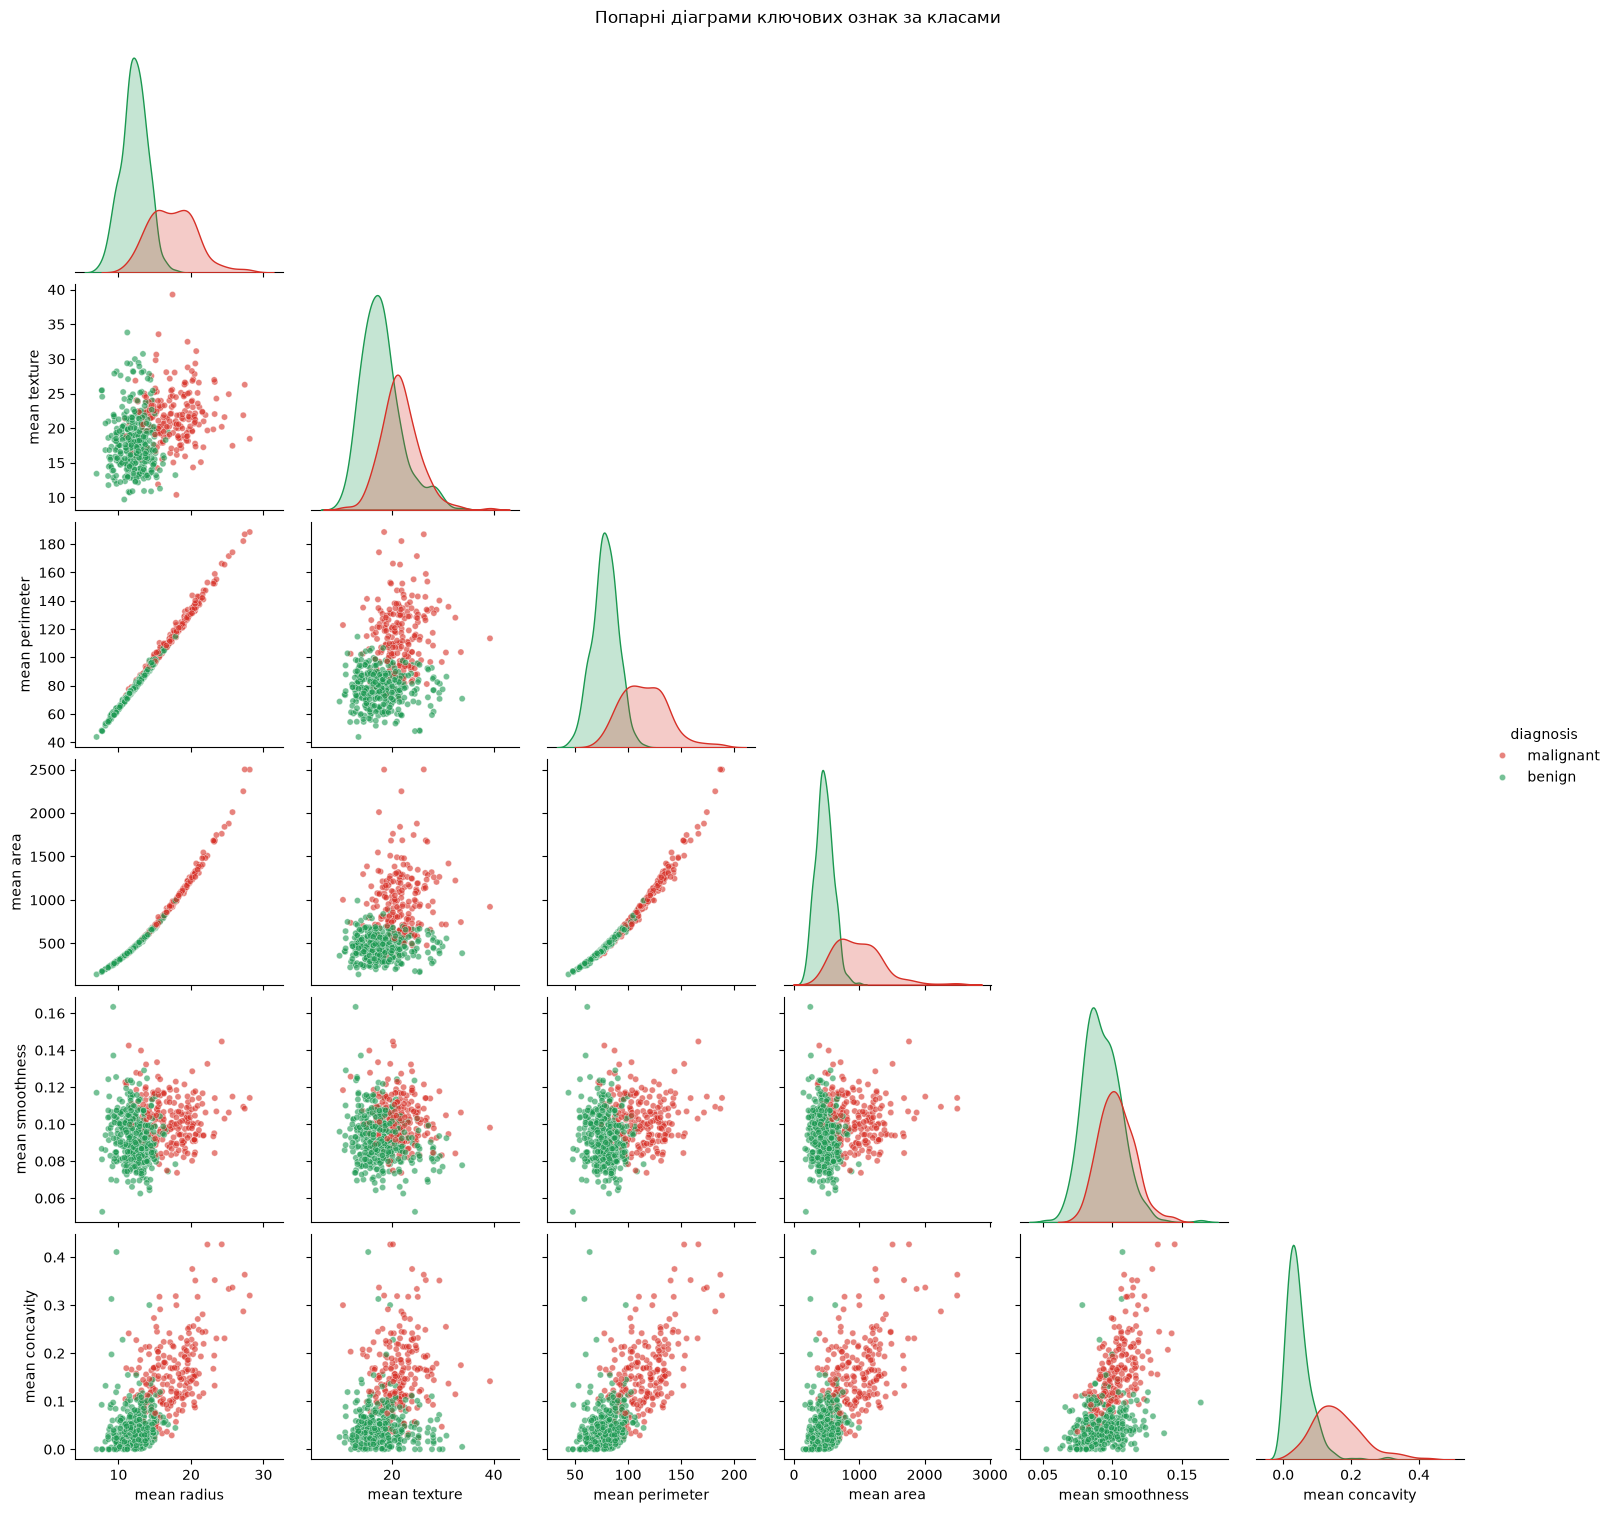

In [3]:
key_features = ['mean radius', 'mean texture', 'mean perimeter',
                'mean area', 'mean smoothness', 'mean concavity']
plot_df = df[key_features + ['target']].copy()
plot_df['diagnosis'] = plot_df['target'].map({0: 'malignant', 1: 'benign'})

sns.pairplot(plot_df.drop(columns='target'), hue='diagnosis',
             palette={'malignant': '#d73027', 'benign': '#1a9850'},
             plot_kws={'alpha': 0.6, 's': 20}, corner=True)
plt.suptitle('Попарні діаграми ключових ознак за класами', y=1.01)
plt.show()

Видно, що злоякісні пухлини (червоні) систематично мають **більші** значення розміру (radius, perimeter, area) та увігнутості — класи помітно, хоч і не ідеально, розділяються вже за окремими ознаками.

## Стандартизація ознак

Ознаки мають різні масштаби (area ~ сотні, smoothness ~ 0.1), тож стандартизуємо їх — це критично і для кластеризації/PCA (працюють з відстанями), і для градієнтного спуску.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   # для кластеризації та PCA (без учителя)
print('Середні після масштабування ≈', np.round(X_scaled.mean(axis=0)[:3], 3),
      ' std ≈', np.round(X_scaled.std(axis=0)[:3], 3))

Середні після масштабування ≈ [-0. -0. -0.]  std ≈ [1. 1. 1.]


## 3. Кластеризація та порівняння з класами

Застосовуємо три методи кластеризації (по 2 кластери) і порівнюємо з фактичними класами через **Adjusted Rand Index (ARI)** та точність після оптимального зіставлення міток кластерів із класами.

In [5]:
def cluster_accuracy(y_true, labels):
    """Точність за найкращого зіставлення міток кластерів із класами (2 класи)."""
    return max(accuracy_score(y_true, labels), accuracy_score(y_true, 1 - labels))


clusterers = {
    'Spectral': SpectralClustering(n_clusters=2, affinity='nearest_neighbors',
                                   n_neighbors=10, random_state=42),
    'K-Means':  KMeans(n_clusters=2, random_state=42, n_init=10),
    'GMM':      GaussianMixture(n_components=2, random_state=42, n_init=5),
}

cluster_labels = {}
print(f'{"Метод":<10}{"ARI":>8}{"Точність":>12}')
print('-' * 30)
for name, algo in clusterers.items():
    labels = algo.fit_predict(X_scaled)
    cluster_labels[name] = labels
    print(f'{name:<10}{adjusted_rand_score(y, labels):>8.3f}{cluster_accuracy(y, labels):>12.3f}')

Метод          ARI    Точність
------------------------------
Spectral     0.761       0.937
K-Means      0.654       0.905
GMM          0.774       0.940


**Пояснення результатів.** Усі три методи **без міток** відтворюють поділ на доброякісні/злоякісні з точністю **90–94%** (ARI 0.65–0.77). Найкраще працюють **GMM** та **Spectral** — вони гнучкіші за K-Means: GMM моделює кластери еліпсоїдами різної форми, а Spectral вловлює нелінійну структуру через граф сусідів. **K-Means** трохи гірший, бо припускає сферичні кластери однакового розміру, що для цих даних не зовсім так. Високий ARI підтверджує: **структура даних сама по собі майже збігається з медичним діагнозом** — ознаки клітин справді несуть сильний сигнал про злоякісність, і це хороший прогноз для подальшої класифікації.

## 4. Зменшення розмірності методом PCA

Проєктуємо 30 ознак у простір **2 головних компонент** для візуалізації та подальшого аналізу структури.

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print('Пояснена дисперсія по компонентах:', np.round(pca.explained_variance_ratio_, 3))
print('Сумарно 2 компоненти пояснюють:', round(pca.explained_variance_ratio_.sum(), 3))

Пояснена дисперсія по компонентах: [0.443 0.19 ]
Сумарно 2 компоненти пояснюють: 0.632


## 5. Візуалізація класів у просторі PCA

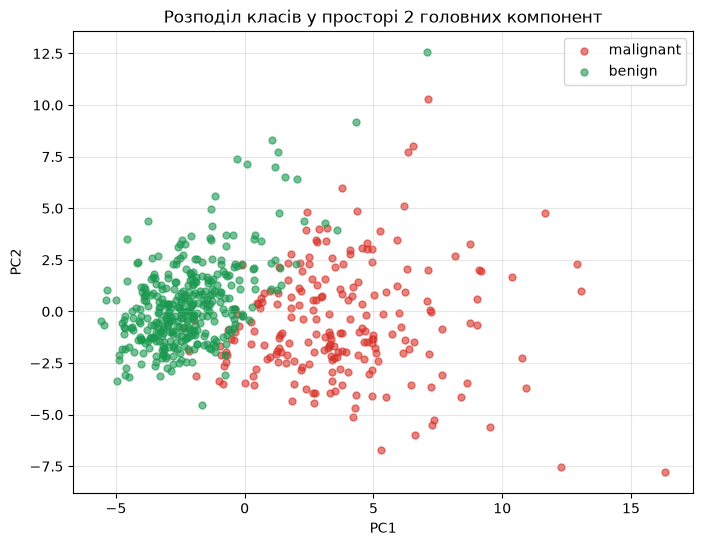

In [7]:
plt.figure(figsize=(8, 6))
for cls, name, color in [(0, 'malignant', '#d73027'), (1, 'benign', '#1a9850')]:
    mask = y == cls
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=name, alpha=0.6, s=25)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Розподіл класів у просторі 2 головних компонент')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Уже у 2D (де збережено ~63% дисперсії) класи **добре розділяються** майже лінійно — це пояснює, чому проста логістична регресія далі дасть високу якість.

## Підготовка до класифікації

Ділимо дані на train/test, масштабуємо (scaler навчаємо **лише на train**, щоб уникнути витоку інформації), додаємо стовпець одиниць (bias) для власних реалізацій.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

sc = StandardScaler().fit(X_train)
X_train_s = sc.transform(X_train)
X_test_s = sc.transform(X_test)

# з bias-стовпцем для власних реалізацій
Xtr = np.column_stack([np.ones(len(X_train_s)), X_train_s])
Xte = np.column_stack([np.ones(len(X_test_s)), X_test_s])
n_samples, n_features = Xtr.shape
print('train:', Xtr.shape, ' test:', Xte.shape)

results = {}   # сюди збиратимемо f1 усіх класифікаторів

train: (398, 31)  test: (171, 31)


## 6. Логістична регресія (`sklearn`) — базова лінія

In [9]:
logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train_s, y_train)
y_pred_sk = logreg.predict(X_test_s)

results['sklearn LogReg'] = f1_score(y_test, y_pred_sk)
print('F1:', round(results['sklearn LogReg'], 4),
      ' Accuracy:', round(accuracy_score(y_test, y_pred_sk), 4))

F1: 0.9907  Accuracy: 0.9883


## 7. Логістична регресія з власним градієнтним спуском

Реалізуємо логістичну регресію «з нуля». Модель: $\hat{p} = \sigma(Xw)$, функція втрат — крос-ентропія, градієнт $\nabla L = \frac{1}{n}X^\top(\sigma(Xw) - y)$. Оптимізуємо вагами кількома методами з конспекту (Тема 5): **Batch GD, SGD, RMSProp, Adam, Nadam**.

In [10]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def log_loss(w):
    p = sigmoid(Xtr @ w)
    return -np.mean(y_train * np.log(p + 1e-12) + (1 - y_train) * np.log(1 - p + 1e-12))

def gradient(w):
    p = sigmoid(Xtr @ w)
    return Xtr.T @ (p - y_train) / n_samples

def predict(w, X):
    return (sigmoid(X @ w) >= 0.5).astype(int)

In [11]:
def train_batch_gd(lr=0.5, n_iter=2000):
    w = np.zeros(n_features); hist = []
    for _ in range(n_iter):
        w -= lr * gradient(w); hist.append(log_loss(w))
    return w, hist

def train_sgd(lr=0.1, n_iter=200):
    w = np.zeros(n_features); hist = []
    for _ in range(n_iter):
        for i in np.random.permutation(n_samples):
            xi = Xtr[i]
            w -= lr * xi * (sigmoid(xi @ w) - y_train[i])
        hist.append(log_loss(w))
    return w, hist

def train_rmsprop(lr=0.05, n_iter=2000, beta=0.9, eps=1e-8):
    w = np.zeros(n_features); Eg2 = np.zeros(n_features); hist = []
    for _ in range(n_iter):
        g = gradient(w); Eg2 = beta * Eg2 + (1 - beta) * g ** 2
        w -= lr * g / (np.sqrt(Eg2) + eps); hist.append(log_loss(w))
    return w, hist

def train_adam(lr=0.1, n_iter=2000, b1=0.9, b2=0.999, eps=1e-8, nesterov=False):
    w = np.zeros(n_features); m_t = np.zeros(n_features); v_t = np.zeros(n_features); hist = []
    for t in range(1, n_iter + 1):
        g = gradient(w)
        m_t = b1 * m_t + (1 - b1) * g
        v_t = b2 * v_t + (1 - b2) * g ** 2
        m_hat = m_t / (1 - b1 ** t); v_hat = v_t / (1 - b2 ** t)
        num = b1 * m_hat + (1 - b1) * g / (1 - b1 ** t) if nesterov else m_hat
        w -= lr * num / (np.sqrt(v_hat) + eps); hist.append(log_loss(w))
    return w, hist

In [12]:
gd_methods = {
    'Batch GD': train_batch_gd(),
    'SGD':      train_sgd(),
    'RMSProp':  train_rmsprop(),
    'Adam':     train_adam(),
    'Nadam':    train_adam(nesterov=True),
}

gd_weights = {}
print(f'{"Метод":<10}{"train loss":>12}{"F1 (test)":>12}{"Accuracy":>12}')
print('-' * 46)
for name, (w, hist) in gd_methods.items():
    gd_weights[name] = (w, hist)
    yp = predict(w, Xte)
    f1 = f1_score(y_test, yp)
    results[f'GD: {name}'] = f1
    print(f'{name:<10}{log_loss(w):>12.4f}{f1:>12.4f}{accuracy_score(y_test, yp):>12.4f}')

Метод       train loss   F1 (test)    Accuracy
----------------------------------------------
Batch GD        0.0444      0.9859      0.9825
SGD             0.0269      0.9770      0.9708
RMSProp         0.0076      0.9626      0.9532
Adam            0.0131      0.9626      0.9532
Nadam           0.0129      0.9626      0.9532


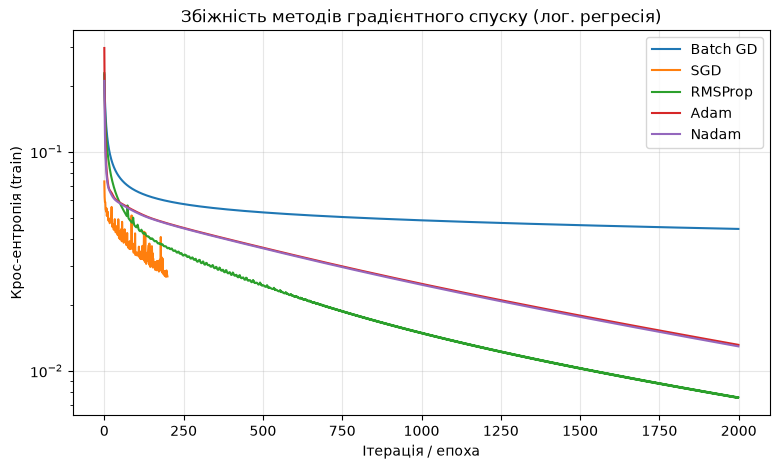

In [13]:
# Криві збіжності (train loss)
plt.figure(figsize=(9, 5))
for name, (w, hist) in gd_weights.items():
    plt.plot(hist, label=name)
plt.xlabel('Ітерація / епоха'); plt.ylabel('Крос-ентропія (train)')
plt.title('Збіжність методів градієнтного спуску (лог. регресія)')
plt.yscale('log'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 8. Логістична регресія з оптимізацією генетичним алгоритмом

Тепер ваги логістичної регресії шукаємо **не градієнтом, а генетичним алгоритмом** (`PyGad`). Кожна хромосома — вектор ваг; фітнес = **мінус крос-ентропія** на train (максимізуємо → мінімізуємо втрати).

In [14]:
def fitness_func(ga_instance, solution, solution_idx):
    return -log_loss(np.array(solution))

ga = pygad.GA(
    num_generations=300,
    num_parents_mating=10,
    sol_per_pop=50,
    num_genes=n_features,
    init_range_low=-2, init_range_high=2,
    fitness_func=fitness_func,
    parent_selection_type='sss',
    crossover_type='two_points',
    mutation_type='random',
    mutation_percent_genes=15,
    random_seed=42,
    suppress_warnings=True,
)
ga.run()

w_ga = np.array(ga.best_solution()[0])
y_pred_ga = predict(w_ga, Xte)
results['GA'] = f1_score(y_test, y_pred_ga)
print('GA train loss:', round(log_loss(w_ga), 4))
print('F1:', round(results['GA'], 4), ' Accuracy:', round(accuracy_score(y_test, y_pred_ga), 4))

GA train loss: 0.0271
F1: 0.9725  Accuracy: 0.9649


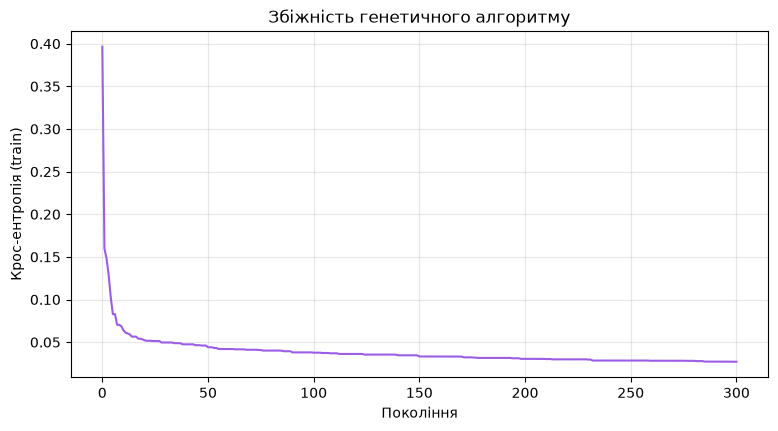

In [15]:
plt.figure(figsize=(9, 4.5))
plt.plot(-np.array(ga.best_solutions_fitness), color='#9b5de5')
plt.xlabel('Покоління'); plt.ylabel('Крос-ентропія (train)')
plt.title('Збіжність генетичного алгоритму')
plt.grid(alpha=0.3)
plt.show()

## 9. Оцінка якості: confusion_matrix та f1_score

Будуємо матриці невідповідностей для всіх ключових класифікаторів.

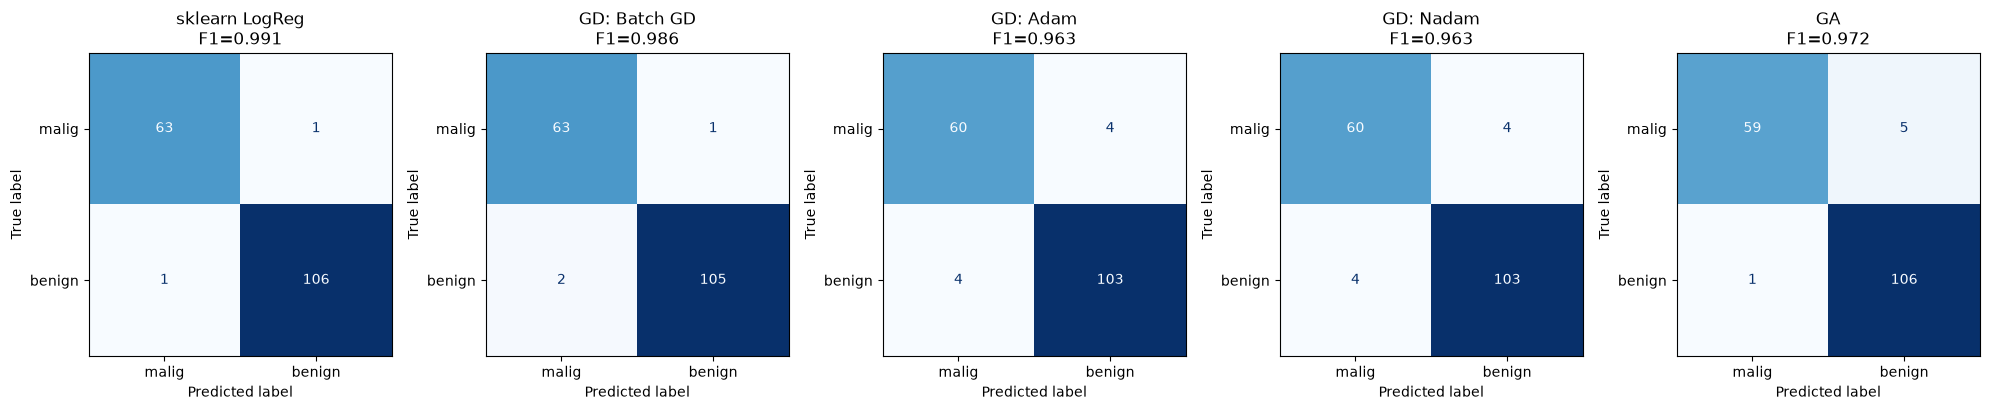

In [16]:
models_pred = {
    'sklearn LogReg': y_pred_sk,
    'GD: Batch GD': predict(gd_weights['Batch GD'][0], Xte),
    'GD: Adam': predict(gd_weights['Adam'][0], Xte),
    'GD: Nadam': predict(gd_weights['Nadam'][0], Xte),
    'GA': y_pred_ga,
}

fig, axes = plt.subplots(1, len(models_pred), figsize=(20, 4))
for ax, (name, yp) in zip(axes, models_pred.items()):
    cm = confusion_matrix(y_test, yp)
    ConfusionMatrixDisplay(cm, display_labels=['malig', 'benign']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nF1={f1_score(y_test, yp):.3f}')
plt.tight_layout()
plt.show()

In [17]:
# Підсумкова таблиця F1 усіх класифікаторів
summary = pd.DataFrame(sorted(results.items(), key=lambda x: -x[1]),
                       columns=['Класифікатор', 'F1-score'])
summary['F1-score'] = summary['F1-score'].round(4)
summary

,Класифікатор,F1-score
0,sklearn LogReg,0.9907
1,GD: Batch GD,0.9859
2,GD: SGD,0.9770
3,GA,0.9725
4,GD: RMSProp,0.9626
5,GD: Adam,0.9626
6,GD: Nadam,0.9626


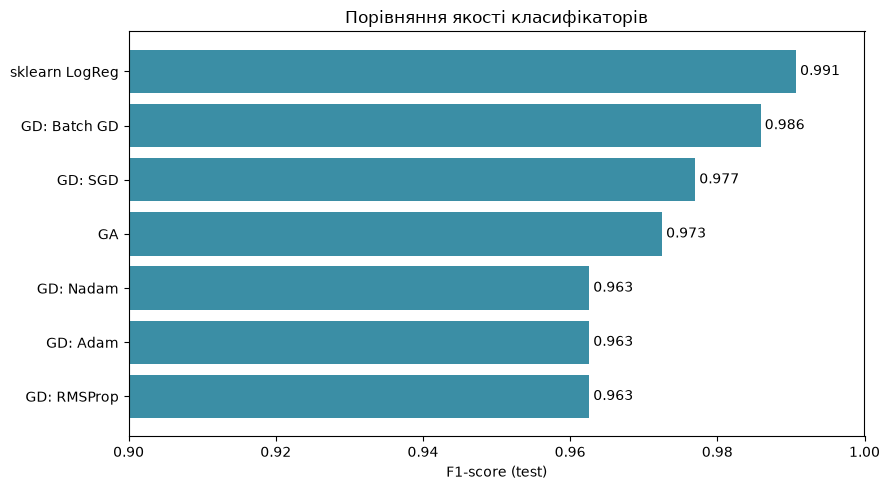

In [18]:
plt.figure(figsize=(9, 5))
s = summary.sort_values('F1-score')
plt.barh(s['Класифікатор'], s['F1-score'], color='#3b8ea5')
plt.xlim(0.9, 1.0)
plt.xlabel('F1-score (test)')
plt.title('Порівняння якості класифікаторів')
for i, v in enumerate(s['F1-score']):
    plt.text(v, i, f' {v:.3f}', va='center')
plt.tight_layout()
plt.show()

## 10. Загальні висновки

**Про структуру даних.** Розвідувальний аналіз, кластеризація та PCA узгоджено показали, що набір Breast Cancer має **сильну внутрішню структуру, що майже збігається з діагнозом**: кластеризація без міток дала 90–94% відповідності класам (найкраще — GMM та Spectral), а у 2D-просторі PCA (≈63% дисперсії) класи розділяються майже лінійно. Це заздалегідь віщувало високу якість лінійного класифікатора.

**Про якість оптимізації параметрів класифікатора.**
- **Усі три підходи** (бібліотечний `LogisticRegression`, власний градієнтний спуск і генетичний алгоритм) досягли **дуже високої та практично однакової якості** — **F1 ≈ 0.96–0.99** на тесті. Різниця між ними — це буквально 1–3 неправильно класифіковані зразки зі 171, тобто в межах статистичного шуму.
- **Градієнтний спуск** — найефективніший за обчисленнями: **адаптивні методи (Adam, Nadam, RMSProp)** доводять train-втрати до мінімуму за десятки ітерацій, тоді як простий **Batch GD** потребує їх більше. Проте на цьому (легко роздільному) наборі надто «агресивна» мінімізація train-втрат адаптивними методами дає **ледь помітне перенавчання**: Batch GD із вищими train-втратами показав трохи кращий test-F1. Це наочний приклад, що **нижчі втрати на навчанні ≠ краще узагальнення**.
- **Генетичний алгоритм** також знайшов якісні ваги (F1 ≈ 0.97) — він **не потребує градієнта** й стійкий до форми функції втрат, але потребує значно **більше обчислень** (сотні поколінь × 50 хромосом) для результату, який градієнтний спуск дає майже миттєво. GA доцільний там, де градієнт недоступний або функція втрат негладка; для гладкої опуклої задачі логістичної регресії градієнтні методи ефективніші.

**Підсумок.** Для добре роздільних даних вибір методу оптимізації майже не впливає на фінальну якість — усі дають майже ідеальний класифікатор. Різниця проявляється в **обчислювальній ефективності** (градієнтні методи, особливо адаптивні, — найшвидші) та в **універсальності** (генетичний алгоритм працює без градієнта, але дорожчий). Коректна підготовка даних (стандартизація, розуміння структури через кластеризацію та PCA) виявилася не менш важливою за сам вибір оптимізатора.